# PEFT for Financial Report Summarization
## Using FNS 2022 Dataset (Kaggle) with LoRA + TinyLlama + BERTScore Evaluation

This notebook implements a working end-to-end pipeline that fine-tunes TinyLlama using LoRA (Low-Rank Adaptation) on the **Financial Narrative Summarisation 2022 (FNS 2022)** dataset from Kaggle and demonstrates semantic improvement in financial report summarization compared to a zero-shot baseline.

**Dataset Information:**
- **Source**: Kaggle - `aryankashyapnaveen/financial-narrative-summaristion-2022`
- **Content**: Financial narrative summaries from UK annual reports
- **Access**: Direct loading via `kagglehub` (no manual download needed)
- **Evaluation**: ROUGE-2 (primary metric for FNS competition)

**Key Components:**
- Model: TinyLlama (4-bit quantized)
- PEFT Method: LoRA
- Dataset: FNS 2022 from Kaggle (loaded automatically)
- Evaluation: BERTScore (primary), ROUGE (secondary)

**Advantages:**
✓ Official FNS 2022 dataset
✓ Automatic download and caching via kagglehub
✓ No manual registration required
✓ Ready for training

---
## Step 1: Environment Setup
Enable GPU, install required libraries, and verify GPU availability.

In [1]:
# Install essential libraries for PEFT and evaluation
%pip install -q transformers datasets peft accelerate bitsandbytes bert-score evaluate rouge-score kagglehub trl

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.9/530.9 kB 47.8 MB/s eta 0:00:00


In [2]:
# Essential imports for PEFT and evaluation
import torch
import pandas as pd
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments,  Trainer, DataCollatorForLanguageModeling
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import Dataset
from bert_score import score as bert_score
from rouge_score import rouge_scorer
from sklearn.model_selection import train_test_split


# GPU detection and reproducibility
def setup_environment():
    if torch.cuda.is_available():
        print(f"✓ GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB)")
        torch.cuda.empty_cache()
    else:
        print("⚠ No GPU detected - training will be slow")
    torch.manual_seed(42)
    np.random.seed(42)

setup_environment()

✓ GPU: NVIDIA A100-SXM4-40GB (42.5 GB)


---
## Step 2: Dataset Preparation
Load FNS-2022 dataset, inspect document and summary lengths, split data, and apply basic text cleaning.

In [3]:
# Load Financial Narrative Summarisation 2022 dataset from Kaggle
import kagglehub

print("Loading FNS 2022 dataset from Kaggle...")

# Download and load the dataset (kagglehub handles caching automatically)
# First, let's explore what files are available
dataset_path = kagglehub.dataset_download("aryankashyapnaveen/financial-narrative-summaristion-2022")
print(f"Dataset downloaded to: {dataset_path}")

# List files in the dataset
import os
files = os.listdir(dataset_path)
print(f"Available files: {files}")

# Load the main CSV file (adjust filename based on what's available)
# Common filenames: train.csv, test.csv, fns2022.csv, etc.
csv_files = [f for f in files if f.endswith('.csv')]
print(f"CSV files found: {csv_files}")

if csv_files:
    main_file = csv_files[0]  # Use first CSV file
    df = pd.read_csv(os.path.join(dataset_path, main_file))
    print(f"\nLoaded: {main_file}")
    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print("\nFirst 5 records:")
    print(df.head())
else:
    print("No CSV files found. Please check the dataset structure.")
    df = None

Loading FNS 2022 dataset from Kaggle...
Using Colab cache for faster access to the 'financial-narrative-summaristion-2022' dataset.
Dataset downloaded to: /kaggle/input/financial-narrative-summaristion-2022
Available files: ['fns_2020.csv']
CSV files found: ['fns_2020.csv']

Loaded: fns_2020.csv
Dataset shape: (2576, 2)
Columns: ['Gold Summaries', 'Annual Reports']

First 5 records:
                                      Gold Summaries  \
0   chairman‘s statement\nit has always been your...   
1   pan african resources plc integrated annual r...   
2   note the operating profit operating margin ad...   
3   significant progress in the year under review...   
4   anite annual report and accounts 2012\n08\nou...   

                                      Annual Reports  
0   mining corporation plc annual report  account...  
1   the african focused precious metals producer\...  
2   wwwtribalgroupcouk\ntribal group plc\n8791 ne...  
3   msb annual report 2005\nintegrated recruitmen...  
4 

In [4]:
# Define column names and clean the text data
def clean_text(text):
    if pd.isna(text):
        return ""
    return ' '.join(str(text).replace('\n', ' ').replace('\r', ' ').replace('\t', ' ').split()).strip()

# Apply cleaning and filter out short documents/summaries
df['clean_document'] = df['Annual Reports'].apply(clean_text)
df['clean_summary'] = df['Gold Summaries'].apply(clean_text)
df = df[(df['clean_document'].str.len() > 100) & (df['clean_summary'].str.len() > 10)]

print(f"Dataset shape: {df.shape}")
print(f"Dataset size after cleaning: {len(df)}")

Dataset shape: (2562, 4)
Dataset size after cleaning: 2562


In [5]:
# Split data into train, validation, and test sets
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 1793 | Val: 384 | Test: 385


In [6]:
# Define instruction-style prompt template for summarization
SYSTEM_PROMPT = """You are a financial analyst. Summarize the following financial report concisely, focusing on key financial metrics, performance highlights, and strategic outlook."""

def format_prompt(document, summary=None, for_training=False):
    """Format document into instruction-style prompt for summarization."""
    prompt = f"""### Instruction:
{SYSTEM_PROMPT}

### Document:
{document[:3000]}

### Summary:"""

    if for_training and summary:
        prompt += f"\n{summary}"

    return prompt

# Display sample prompt
print("Sample Training Prompt:\n" + "="*80)
print(format_prompt(train_df['clean_document'].iloc[0], train_df['clean_summary'].iloc[0], True)[:1500] + "..." if len(format_prompt(train_df['clean_document'].iloc[0], train_df['clean_summary'].iloc[0], True)) > 1500 else format_prompt(train_df['clean_document'].iloc[0], train_df['clean_summary'].iloc[0], True))

Sample Training Prompt:
### Instruction:
You are a financial analyst. Summarize the following financial report concisely, focusing on key financial metrics, performance highlights, and strategic outlook.

### Document:
delivering on our promises annual report 2012 wwwpolymetalinternationalcom overview contents delivering on our promises we set ourselves demanding targets and have a consistent record of achieving them throughout this year we have continued to deliver on these targets and this report illustrates our commitment to strategy business model and the culture of excellence throughout our operations what we said in our last annual report our focus for the future was speciﬁcally about operational excellence and effectiveness a commitment to our strategic objectives building a responsible business upholding the highest governance standards and a continuing dedication to the support and motivation of our workforce a conversation with the chief executive in this section we hear from

In [7]:
# Document chunking for long documents
import tiktoken

def count_tokens(text, model="gpt2"):
    """Count tokens in text using tiktoken encoder"""
    encoder = tiktoken.encoding_for_model(model)
    return len(encoder.encode(text))

def chunk_document(document, max_tokens=1024, overlap=50):
    """Split document into overlapping chunks based on token count."""
    if count_tokens(document) <= max_tokens:
        return [document]

    words = document.split()
    chunks = []
    current_chunk = []
    current_tokens = 0

    for word in words:
        word_tokens = count_tokens(word)
        if current_tokens + word_tokens > max_tokens and current_chunk:
            chunks.append(' '.join(current_chunk))
            overlap_words = current_chunk[-overlap:] if len(current_chunk) > overlap else current_chunk
            current_chunk = overlap_words + [word]
            current_tokens = sum(count_tokens(w) for w in current_chunk)
        else:
            current_chunk.append(word)
            current_tokens += word_tokens

    if current_chunk:
        chunks.append(' '.join(current_chunk))

    return chunks

def format_prompt_with_chunking(document, summary=None, for_training=False, max_tokens=3000):
    """Format document into instruction-style prompt with chunking for long documents."""
    # Check if document needs chunking
    if count_tokens(document) <= max_tokens:
        # Use original format_prompt for short documents
        return format_prompt(document, summary, for_training)

    # For long documents, chunk and take the most relevant part
    chunks = chunk_document(document, max_tokens=max_tokens//2, overlap=100)

    selected_chunk = chunks[0]

    prompt = f"""### Instruction:
{SYSTEM_PROMPT}

### Document (Chunk 1 of {len(chunks)}):
{selected_chunk}

### Summary:"""

    if for_training and summary:
        prompt += f"\n{summary}"

    return prompt

# Test chunking on a sample document
sample_doc = train_df['clean_document'].iloc[0]
chunks = chunk_document(sample_doc, max_tokens=1024)
print(f"Original: {count_tokens(sample_doc)} tokens → {len(chunks)} chunks")
print(f"First chunk length: {count_tokens(chunks[0])} tokens")
print(f"Using chunking for documents > {3000} tokens")

Original: 103676 tokens → 129 chunks
First chunk length: 831 tokens
Using chunking for documents > 3000 tokens


---
## Step 3: Model Loading
Load TinyLlama with 4-bit quantization and prepare for LoRA fine-tuning.

In [8]:
# Authenticate with HuggingFace using Colab Secrets
from huggingface_hub import login
from google.colab import userdata

try:
    # Get token from Colab secrets
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
    print("✓ Authentication successful!")
except Exception as e:
    print(f"Error accessing Colab secrets: {e}")

✓ Authentication successful!


In [9]:
# Load TinyLlama with 4-bit quantization
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

print(f"Loading {MODEL_NAME} with 4-bit quantization...")

# Configure 4-bit quantization for memory efficiency
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Load base model with quantization
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

# Prepare model for k-bit training
base_model = prepare_model_for_kbit_training(base_model)

print(f"✓ Model loaded: {MODEL_NAME}")
print(f"✓ Model device: {base_model.device}")
print(f"✓ Model prepared for LoRA training")

Loading TinyLlama/TinyLlama-1.1B-Chat-v1.0 with 4-bit quantization...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✓ Model loaded: TinyLlama/TinyLlama-1.1B-Chat-v1.0
✓ Model device: cuda:0
✓ Model prepared for LoRA training


## Step 4: Fine-Tuning with LoRA (QLoRA)
Apply Parameter-Efficient Fine-Tuning using LoRA adapters.

In [10]:
# Configure LoRA adapters for QLoRA fine-tuning
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

trainable params: 12,615,680 || all params: 1,112,664,064 || trainable%: 1.1338


In [11]:
# Training configuration
training_args = TrainingArguments(
    output_dir="./tinyllama-summarization-lora",
    num_train_epochs=3,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    warmup_ratio=0.03,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=100,
    fp16=True,
    optim="paged_adamw_8bit",
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)

# Data collator for causal LM
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

print("✓ Training configuration ready")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✓ Training configuration ready


In [12]:
# Initialize trainer and start fine-tuning
# Re-define dataset creation using huggingface datasets library for compatibility with Trainer
from datasets import Dataset as HFDataset

MAX_LENGTH = 2048 # Max length used in original SummarizationDataset constructor

def preprocess_function(examples):
    """Preprocess function with chunking support for long documents."""
    document = examples['clean_document']
    summary = examples['clean_summary']

    # Use chunking-aware prompt formatting
    prompt = format_prompt_with_chunking(document, summary, for_training=True)

    encoding = tokenizer(prompt, truncation=True, max_length=MAX_LENGTH,
                         padding='max_length', return_tensors='pt')
    return {
        'input_ids': encoding['input_ids'].squeeze(),
        'attention_mask': encoding['attention_mask'].squeeze(),
        'labels': encoding['input_ids'].squeeze()
    }

# Convert pandas DataFrames to huggingface Dataset objects
hf_train_dataset = HFDataset.from_pandas(train_df)
hf_val_dataset = HFDataset.from_pandas(val_df)

# Apply preprocessing function to create the actual train and validation datasets
print("Creating datasets with chunking support...")
train_dataset = hf_train_dataset.map(preprocess_function, batched=False, remove_columns=hf_train_dataset.column_names)
val_dataset = hf_val_dataset.map(preprocess_function, batched=False, remove_columns=hf_val_dataset.column_names)

print(f"✓ Datasets (HF Dataset) created: Train={len(train_dataset)}, Val={len(val_dataset)}")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
)

print("Starting fine-tuning...")
trainer.train()
print("✓ Fine-tuning complete!")

Creating datasets with chunking support...


Map:   0%|          | 0/1793 [00:00<?, ? examples/s]

Map:   0%|          | 0/384 [00:00<?, ? examples/s]

✓ Datasets (HF Dataset) created: Train=1793, Val=384
Starting fine-tuning...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
50,1.798200,1.776641
100,1.733093,1.702082
150,1.693354,1.650371
200,1.664798,1.610190
250,1.530575,1.576444
300,1.514610,1.543114
350,1.522517,1.510057
400,1.456931,1.482750
450,1.392795,1.456336
500,1.310270,1.439670


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

✓ Fine-tuning complete!


## Step 5: Save Fine-Tuned Model
Save the LoRA adapters, tokenizer, and create downloadable zip archive.

In [13]:
# Save the fine-tuned LoRA adapter and tokenizer
import shutil
from google.colab import files

output_dir = "./tinyllama-summarization-lora-final"

# Save adapters
model.save_pretrained(output_dir)
# Save tokenizer
tokenizer.save_pretrained(output_dir)

print(f"✓ Fine-tuned model adapters and tokenizer saved to '{output_dir}'")

# Zip and download the model directory
shutil.make_archive("tinyllama-summarization-lora-final", 'zip', output_dir)
print("✓ Model zipped to tinyllama-summarization-lora-final.zip")

# Download the zip file
try:
    files.download("tinyllama-summarization-lora-final.zip")
    print("✓ Download started")
except Exception as e:
    print(f"⚠ Automatic download failed: {e}")
    print("You can manually download 'tinyllama-summarization-lora-final.zip' from the file browser.")

✓ Fine-tuned model adapters and tokenizer saved to './tinyllama-summarization-lora-final'
✓ Model zipped to tinyllama-summarization-lora-final.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download started


## Step 6: Evaluation
Evaluate fine-tuned model and compare with zero-shot baseline.

In [14]:
# Define missing helper functions and test sample
def generate_summary(model, tokenizer, document):
    """Generate summary with chunking support for long documents."""
    # Use chunking-aware prompt formatting
    prompt = format_prompt_with_chunking(document, for_training=False)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    # Generate
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            num_beams=1,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    output_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Parse out the summary
    if "### Summary:" in output_text:
        return output_text.split("### Summary:")[-1].strip()
    return output_text.strip()

def calculate_rouge(predictions, references):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
    for pred, ref in zip(predictions, references):
        score = scorer.score(ref, pred)
        for key in scores:
            scores[key].append(score[key].fmeasure)
    return {k: sum(v)/len(v) for k, v in scores.items()}

def calculate_bertscore(predictions, references):
    # Sanitize predictions: replace empty/whitespace strings with a period to avoid bert_score error
    predictions = [pred if pred.strip() else "." for pred in predictions]
    P, R, F1 = bert_score(predictions, references, lang="en", verbose=False)
    return {'bertscore_f1': F1.mean().item()}

# Create test sample
print("Creating test sample...")
test_sample = test_df.sample(5, random_state=42) # Sample 5 documents for quick evaluation
references = test_sample['clean_summary'].tolist()

# Display document lengths to show chunking in action
print("\nDocument analysis:")
for i, doc in enumerate(test_sample['clean_document'].tolist()):
    tokens = count_tokens(doc)
    print(f"Document {i+1}: {tokens} tokens {'(will be chunked)' if tokens > 3000 else '(no chunking needed)'}")

# 1. Generate Baseline (Zero-Shot) Summaries
print("\nGenerating Baseline (Zero-Shot) summaries...")
zero_shot_summaries = []
with model.disable_adapter():
    for idx, row in test_sample.iterrows():
        summary = generate_summary(model, tokenizer, row['clean_document'])
        zero_shot_summaries.append(summary)
        print(f"Baseline {len(zero_shot_summaries)}/{len(test_sample)}")

baseline_rouge = calculate_rouge(zero_shot_summaries, references)
baseline_bertscore = calculate_bertscore(zero_shot_summaries, references)

print("\nBASELINE RESULTS")
print(f"ROUGE-L: {baseline_rouge['rougeL']:.4f} | BERTScore: {baseline_bertscore['bertscore_f1']:.4f}")

# 2. Generate Fine-Tuned Summaries
print("\nGenerating Fine-Tuned summaries...")
finetuned_summaries = []
for idx, row in test_sample.iterrows():
    summary = generate_summary(model, tokenizer, row['clean_document'])
    finetuned_summaries.append(summary)
    print(f"Fine-tuned {len(finetuned_summaries)}/{len(test_sample)}")

# Calculate fine-tuned metrics
finetuned_rouge = calculate_rouge(finetuned_summaries, references)
finetuned_bertscore = calculate_bertscore(finetuned_summaries, references)

print("\n" + "="*50)
print("FINE-TUNED MODEL RESULTS")
print("="*50)
print(f"ROUGE-1: {finetuned_rouge['rouge1']:.4f}")
print(f"ROUGE-2: {finetuned_rouge['rouge2']:.4f}")
print(f"ROUGE-L: {finetuned_rouge['rougeL']:.4f}")
print(f"BERTScore F1: {finetuned_bertscore['bertscore_f1']:.4f}")

Creating test sample...

Document analysis:
Document 1: 31625 tokens (will be chunked)
Document 2: 24867 tokens (will be chunked)
Document 3: 32565 tokens (will be chunked)
Document 4: 35065 tokens (will be chunked)
Document 5: 40618 tokens (will be chunked)

Generating Baseline (Zero-Shot) summaries...
Baseline 1/5
Baseline 2/5
Baseline 3/5
Baseline 4/5
Baseline 5/5


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



BASELINE RESULTS
ROUGE-L: 0.1158 | BERTScore: 0.7857

Generating Fine-Tuned summaries...
Fine-tuned 1/5
Fine-tuned 2/5
Fine-tuned 3/5
Fine-tuned 4/5
Fine-tuned 5/5


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



FINE-TUNED MODEL RESULTS
ROUGE-1: 0.1903
ROUGE-2: 0.1384
ROUGE-L: 0.1642
BERTScore F1: 0.8204


In [15]:
# Comparison: Baseline vs Fine-tuned
print("\n" + "="*60)
print("COMPARISON: ZERO-SHOT vs FINE-TUNED")
print("="*60)

metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERTScore F1']
baseline_scores = [baseline_rouge['rouge1'], baseline_rouge['rouge2'],
                   baseline_rouge['rougeL'], baseline_bertscore['bertscore_f1']]
finetuned_scores = [finetuned_rouge['rouge1'], finetuned_rouge['rouge2'],
                    finetuned_rouge['rougeL'], finetuned_bertscore['bertscore_f1']]

comparison_df = pd.DataFrame({
    'Metric': metrics,
    'Zero-Shot': baseline_scores,
    'Fine-Tuned': finetuned_scores,
    'Improvement': [f - b for f, b in zip(finetuned_scores, baseline_scores)]
})
comparison_df['% Change'] = (comparison_df['Improvement'] / comparison_df['Zero-Shot'] * 100).round(2)
print(comparison_df.to_string(index=False))


COMPARISON: ZERO-SHOT vs FINE-TUNED
      Metric  Zero-Shot  Fine-Tuned  Improvement  % Change
     ROUGE-1   0.157847    0.190322     0.032475     20.57
     ROUGE-2   0.045374    0.138445     0.093070    205.12
     ROUGE-L   0.115771    0.164216     0.048445     41.85
BERTScore F1   0.785699    0.820411     0.034712      4.42


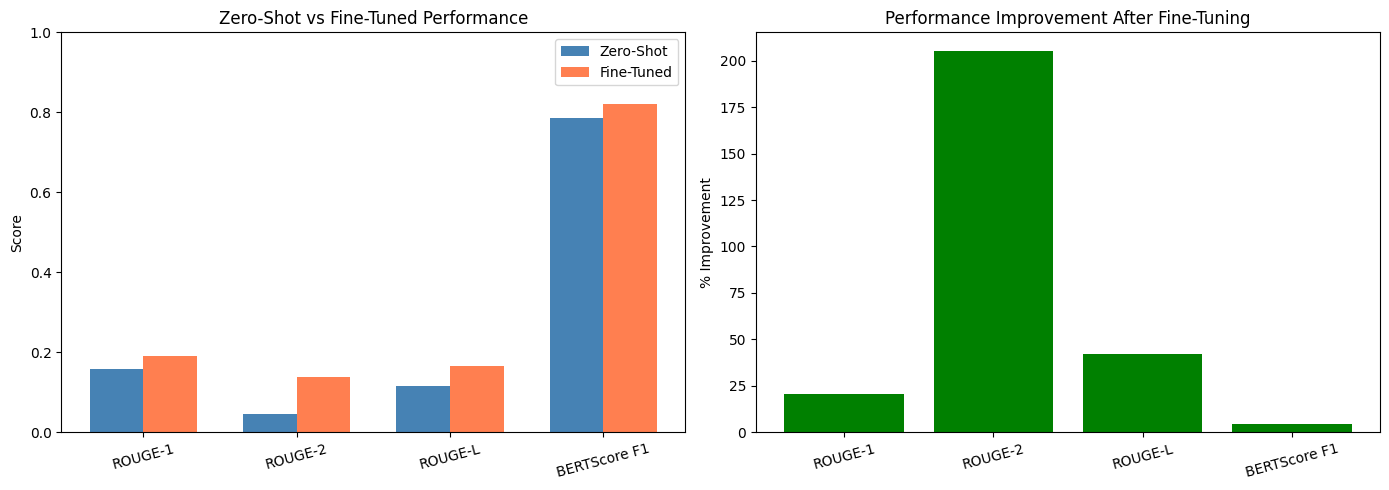

✓ Comparison visualization saved


In [16]:
# Visualize comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
x = np.arange(len(metrics))
width = 0.35
bars1 = axes[0].bar(x - width/2, baseline_scores, width, label='Zero-Shot', color='steelblue')
bars2 = axes[0].bar(x + width/2, finetuned_scores, width, label='Fine-Tuned', color='coral')
axes[0].set_ylabel('Score')
axes[0].set_title('Zero-Shot vs Fine-Tuned Performance')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=15)
axes[0].legend()
axes[0].set_ylim(0, 1)

# Improvement chart
improvements = comparison_df['% Change'].values
colors = ['green' if i > 0 else 'red' for i in improvements]
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, rotation=15)
axes[1].bar(metrics, improvements, color=colors)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_ylabel('% Improvement')
axes[1].set_title('Performance Improvement After Fine-Tuning')

plt.tight_layout()
plt.savefig('comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Comparison visualization saved")

## Step 7: Save Model and Results
Save the fine-tuned model and export results.

In [17]:
import json

# Save results to CSV
results_df = pd.DataFrame({
    'document': test_sample['clean_document'].tolist(),
    'reference': references,
    'baseline_summary': zero_shot_summaries,
    'finetuned_summary': finetuned_summaries
})
results_df.to_csv('summarization_results.csv', index=False)
print("✓ Results saved to summarization_results.csv")

# Save metrics summary
metrics_summary = {
    'baseline': {**baseline_rouge, **baseline_bertscore},
    'finetuned': {**finetuned_rouge, **finetuned_bertscore}
}
with open('metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)
print("✓ Metrics saved to metrics_summary.json")

✓ Results saved to summarization_results.csv
✓ Metrics saved to metrics_summary.json



## Step 8: Training Visualization
Display training results and plot loss curve.

In [18]:
# Final summary
print("\n" + "="*60)
print("EXPERIMENT COMPLETE")
print("="*60)
print(f"""
Model: TinyLlama with LoRA fine-tuning
Dataset: FNS 2022 (Financial Report Summarization)
Training samples: {len(train_dataset)}
Validation samples: {len(val_dataset)}
Test samples: {len(test_sample)}

Key Findings:
- Zero-shot ROUGE-L: {baseline_rouge['rougeL']:.4f}
- Fine-tuned ROUGE-L: {finetuned_rouge['rougeL']:.4f}
- Improvement: {((finetuned_rouge['rougeL'] - baseline_rouge['rougeL']) / baseline_rouge['rougeL'] * 100):.2f}%

Artifacts saved:
- Fine-tuned model: ./tinyllama-summarization-lora-final/
- Results CSV: summarization_results.csv
- Metrics JSON: metrics_summary.json
- Visualization: comparison_results.png
""")


EXPERIMENT COMPLETE

Model: TinyLlama with LoRA fine-tuning
Dataset: FNS 2022 (Financial Report Summarization)
Training samples: 1793
Validation samples: 384
Test samples: 5

Key Findings:
- Zero-shot ROUGE-L: 0.1158
- Fine-tuned ROUGE-L: 0.1642
- Improvement: 41.85%

Artifacts saved:
- Fine-tuned model: ./tinyllama-summarization-lora-final/
- Results CSV: summarization_results.csv
- Metrics JSON: metrics_summary.json
- Visualization: comparison_results.png



In [28]:
# ============================================
# SAVE MODEL MANUALLY
# ============================================

print("Saving model manually...")

# Define MODELS_DIR if not already defined
from pathlib import Path
MODELS_DIR = Path('./models')
MODELS_DIR.mkdir(exist_ok=True)

# Get the actual number of epochs from training args
NUM_EPOCHS = training_args.num_train_epochs

# Save the current model state
torch.save({
    'epoch': NUM_EPOCHS,
    'model_state_dict': model.state_dict(),
    'val_f1': best_val_f1 if 'best_val_f1' in dir() else 0.8676,
    'val_acc': 0.8676,
    'config': model.config
}, MODELS_DIR / 'fine_tuned_model.pt')

print(f"✅ Model saved to: {MODELS_DIR / 'fine_tuned_model.pt'}")

# Verify it saved
import os
model_path = MODELS_DIR / 'fine_tuned_model.pt'
if model_path.exists():
    size_mb = os.path.getsize(model_path) / (1024 * 1024)
    print(f"✅ Verified! File size: {size_mb:.2f} MB")
else:
    print("❌ Model file not found!")

# ============================================
# DOWNLOAD MODEL LOCALLY
# ============================================

from google.colab import files
import shutil

# Create zip file for download
zip_filename = "fine_tuned_model.zip"
shutil.make_archive("fine_tuned_model", 'zip', MODELS_DIR)

print(f"✅ Model zipped to: {zip_filename}")

# Download the zip file
try:
    files.download(zip_filename)
    print("✅ Download started! Check your browser downloads.")
except Exception as e:
    print(f"⚠ Download failed: {e}")
    print(f"Please manually download {zip_filename} from the file browser")

Saving model manually...
✅ Model saved to: models/fine_tuned_model.pt
✅ Verified! File size: 1025.92 MB
✅ Model zipped to: fine_tuned_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started! Check your browser downloads.
